# 02 — Shuttlecock Tracking (FineBadminton)

Runs **TrackNetV4** on every FineBadminton rally to extract per-frame shuttle positions.

**Model**: `tracknet-series-pytorch` (local clone in `datasets/`)
- Input: 3 consecutive RGB frames stacked → `[1, 9, 288, 512]`
- Output: 3 heatmaps with motion attention → argmax of center-frame heatmap gives shuttle pixel (x, y)
- V4 adds a learnable `MotionPrompt` layer that computes inter-frame differences as an attention map, helping focus on fast-moving objects. Same input/output shape as V2 — drop-in upgrade.

**Output per rally**: `datasets_preprocessing/finebadminton_shuttles/{rally_id}.npy`
- Shape: `(T, 3)` — columns are `[x, y, visible]`
- `x, y` in original pixel space (1280 × 720)
- `visible = 1.0` if max heatmap confidence ≥ threshold, else `0.0`

**Steps**:
1. Download pretrained weights (once)
2. Load V4 model & verify forward pass
3. Extract shuttle trajectories for all rallies
4. Verify quality — overlay on actual frames, plot trajectories

In [ ]:
import sys, os
sys.path.insert(0, '..')
sys.path.insert(0, '../datasets/tracknet-series-pytorch')

import cv2
import numpy as np
import torch
import matplotlib.pyplot as plt
from pathlib import Path
from collections import defaultdict
from tqdm import tqdm

from src.config import FB_FRAMES, PROJECT_ROOT

SHUTTLE_DIR = PROJECT_ROOT / 'datasets_preprocessing' / 'finebadminton_shuttles'
WEIGHTS_DIR = PROJECT_ROOT / 'datasets' / 'tracknet-series-pytorch' / 'checkpoints'
WEIGHTS_V4  = WEIGHTS_DIR / 'tracknet-v4_best-model.pth'
WEIGHTS_V2  = WEIGHTS_DIR / 'tracknet-v2_best-model.pth'  # fallback

SHUTTLE_DIR.mkdir(parents=True, exist_ok=True)
WEIGHTS_DIR.mkdir(parents=True, exist_ok=True)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')
print(f'Shuttle output dir: {SHUTTLE_DIR}')


Device: cpu
Shuttle output dir: /Users/yuen@backbase.com/Documents/Baddiev2/datasets_preprocessing/finebadminton_shuttles


## 1. Download Pretrained Weights

Downloads `tracknet-v2_best-model.pth` from the GitHub release (once — skips if already present).

In [8]:
import urllib.request

RELEASE = 'https://github.com/AnInsomniacy/tracknet-series-pytorch/releases/download/v1.0.1'
weights_to_download = [
    ('tracknet-v4_best-model.pth', WEIGHTS_V4),
    ('tracknet-v2_best-model.pth', WEIGHTS_V2),  # also grab V2 for comparison
]

for filename, dest in weights_to_download:
    if dest.exists():
        print(f'  [SKIP] {filename} already downloaded ({dest.stat().st_size/1e6:.1f} MB)')
    else:
        url = f'{RELEASE}/{filename}'
        print(f'  Downloading {filename}...')
        urllib.request.urlretrieve(url, dest)
        print(f'  Saved → {dest} ({dest.stat().st_size/1e6:.1f} MB)')


  [SKIP] tracknet-v4_best-model.pth already downloaded (136.1 MB)
  [SKIP] tracknet-v2_best-model.pth already downloaded (136.1 MB)


## 2. Load TrackNetV4 & Verify Forward Pass

In [9]:
from model.tracknet_v4 import TrackNet

model = TrackNet().to(DEVICE)
checkpoint = torch.load(WEIGHTS_V4, map_location=DEVICE)
state_dict = checkpoint.get('model_state_dict', checkpoint)
model.load_state_dict(state_dict)
model.eval()

params = sum(p.numel() for p in model.parameters())
print(f'TrackNetV4 loaded — {params:,} parameters')
print(f'  (V4 adds MotionPrompt: learnable inter-frame difference attention)')

# Sanity-check forward pass
dummy = torch.zeros(1, 9, 288, 512).to(DEVICE)
with torch.no_grad():
    out = model(dummy)
print(f'Forward pass: {tuple(dummy.shape)} → {tuple(out.shape)}')
print('Output range:', out.min().item(), '–', out.max().item())


TrackNetV4 loaded — 11,334,149 parameters
  (V4 adds MotionPrompt: learnable inter-frame difference attention)
Forward pass: (1, 9, 288, 512) → (1, 3, 288, 512)
Output range: 0.004721830133348703 – 0.014213678427040577


## 3. Shuttle Extraction Helper

In [5]:
IMG_W, IMG_H = 1280, 720   # FineBadminton native resolution
MODEL_W, MODEL_H = 512, 288  # TrackNet input resolution
THRESHOLD = 0.5              # min heatmap confidence to declare detection


def preprocess_frame(bgr_frame):
    """BGR frame → (3, 288, 512) float32 tensor in [0,1]."""
    resized = cv2.resize(bgr_frame, (MODEL_W, MODEL_H))
    t = torch.from_numpy(resized.astype(np.float32) / 255.0).permute(2, 0, 1)
    return t  # (3, 288, 512)


def heatmap_to_xy(heatmap, orig_w=IMG_W, orig_h=IMG_H, threshold=THRESHOLD):
    """
    Decode a single (288, 512) heatmap → (x, y, visible) in original pixel space.
    Returns (0.0, 0.0, 0.0) when max confidence < threshold.
    """
    conf = float(heatmap.max())
    if conf < threshold:
        return 0.0, 0.0, 0.0
    idx = np.unravel_index(np.argmax(heatmap), heatmap.shape)  # (row, col)
    model_y, model_x = idx
    x = model_x * (orig_w / MODEL_W)
    y = model_y * (orig_h / MODEL_H)
    return float(x), float(y), 1.0


@torch.no_grad()
def extract_shuttle_trajectory(frames, batch_size=8):
    """
    Extract shuttle (x, y, visible) for every frame in a rally.

    Uses a sliding window of 3 consecutive frames.
    For the middle frames (1 … T-2) we use the centre heatmap (output[:, 1]).
    For frame 0 we use the first triplet's first heatmap (output[:, 0]).
    For frame T-1 we use the last triplet's last heatmap (output[:, 2]).

    Args:
        frames: list of BGR numpy arrays, all at native resolution
        batch_size: number of triplets per forward pass

    Returns:
        trajectory: np.ndarray (T, 3) — [x, y, visible]
    """
    T = len(frames)
    trajectory = np.zeros((T, 3), dtype=np.float32)

    if T < 3:
        return trajectory

    # Pre-process all frames once
    tensors = [preprocess_frame(f) for f in frames]  # list of (3, H, W)

    # Build sliding-window triplets
    # triplet i → frames [i, i+1, i+2], heatmap output is (3 channels)
    triplets = [
        torch.cat(tensors[i:i+3], dim=0).unsqueeze(0)  # (1, 9, H, W)
        for i in range(T - 2)
    ]

    heatmaps = np.zeros((T - 2, 3, MODEL_H, MODEL_W), dtype=np.float32)

    for start in range(0, len(triplets), batch_size):
        batch = torch.cat(triplets[start:start+batch_size], dim=0).to(DEVICE)  # (B, 9, H, W)
        out   = model(batch).cpu().numpy()  # (B, 3, H, W)
        heatmaps[start:start+len(batch)] = out

    # Frame 0: use triplet-0 output channel 0
    trajectory[0] = heatmap_to_xy(heatmaps[0, 0])

    # Frames 1 … T-2: centre heatmap of each triplet
    for i in range(1, T - 1):
        trajectory[i] = heatmap_to_xy(heatmaps[i - 1, 1])

    # Frame T-1: use last triplet output channel 2
    trajectory[T - 1] = heatmap_to_xy(heatmaps[-1, 2])

    return trajectory


print('Helper functions defined.')
print(f'Threshold: {THRESHOLD}  |  Model res: {MODEL_W}×{MODEL_H}  |  Output space: {IMG_W}×{IMG_H}')


Helper functions defined.
Threshold: 0.5  |  Model res: 512×288  |  Output space: 1280×720


## 4. Extract Trajectories (MVP then Full)

Set `MVP_MODE = True` to test on one rally first.

In [ ]:
MVP_MODE   = False   # ← False to process all rallies
MVP_RALLIES = 1

# Group frames by rally
rally_frames = defaultdict(list)
for f in sorted(FB_FRAMES.glob('*.jpg')):
    parts = f.stem.split('_')
    if len(parts) >= 3:
        rid = f'{parts[0]}_{parts[1]}'
        rally_frames[rid].append((int(parts[2]), f))

already_done = {p.stem for p in SHUTTLE_DIR.glob('*.npy')}
rally_items  = [(r, v) for r, v in sorted(rally_frames.items()) if r not in already_done]

if MVP_MODE:
    rally_items = rally_items[:MVP_RALLIES]
    print(f'MVP mode — {len(rally_items)} rally')
else:
    print(f'Full mode — {len(rally_items)} rallies to process ({len(already_done)} already done)')

for rally_id, frame_list in tqdm(rally_items, desc='Rallies'):
    out_path = SHUTTLE_DIR / f'{rally_id}.npy'
    frame_list.sort(key=lambda x: x[0])
    frames = [cv2.imread(str(fp)) for _, fp in frame_list]
    traj = extract_shuttle_trajectory(frames)
    np.save(out_path, traj)
    visible = int(traj[:, 2].sum())
    tqdm.write(f'  {rally_id}: T={len(frames)}, detected={visible}/{len(frames)} ({100*visible/len(frames):.0f}%)')

done = sorted(SHUTTLE_DIR.glob('*.npy'))
print(f'\nShuttle .npy files: {len(done)}')


Full mode — 35 rallies to process (5 already done)


Rallies:   0%|          | 0/35 [00:13<?, ?it/s]


KeyboardInterrupt: 

## 5. Verify — Overlay on Actual Frames

Draws the detected shuttle position on 8 evenly-spaced frames, and shows
a 10-frame trailing arc to visualise direction.

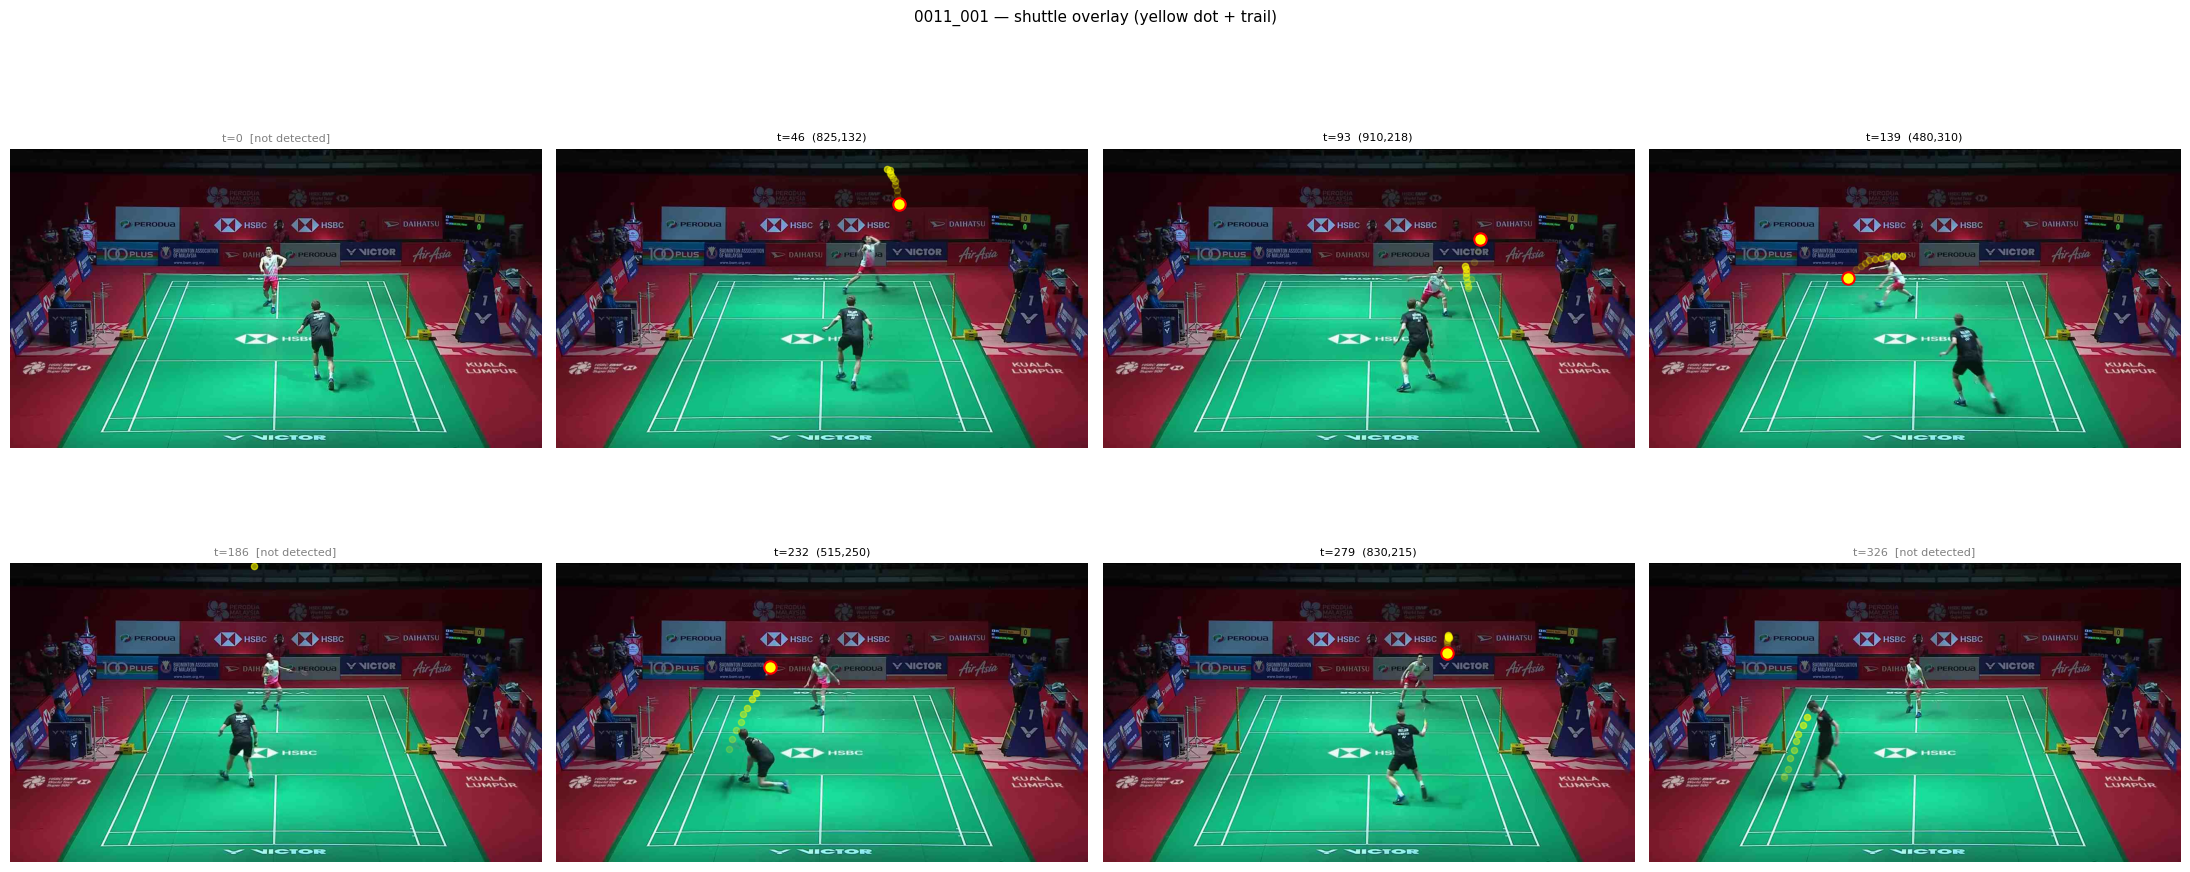

In [6]:
TRAIL = 10   # frames to show as fading trail

done_files = sorted(SHUTTLE_DIR.glob('*.npy'))
if not done_files:
    print('No trajectory files yet — run Section 4 first.')
else:
    for traj_file in done_files[:2]:   # show first 2 rallies
        rally_id = traj_file.stem
        traj = np.load(traj_file)       # (T, 3)

        this_frames = sorted(
            [(int(fp.stem.split('_')[2]), fp)
             for fp in FB_FRAMES.glob(f'{rally_id}_*.jpg')],
            key=lambda x: x[0]
        )
        T = min(len(traj), len(this_frames))

        # 8-frame grid
        idxs = np.linspace(0, T - 1, 8, dtype=int)
        fig, axes = plt.subplots(2, 4, figsize=(22, 10))

        for ax, t in zip(axes.flat, idxs):
            _, fp = this_frames[t]
            img = cv2.cvtColor(cv2.imread(str(fp)), cv2.COLOR_BGR2RGB)

            ax.imshow(img)

            # Trail
            for dt in range(TRAIL, 0, -1):
                ti = t - dt
                if ti >= 0 and traj[ti, 2] > 0:
                    alpha = dt / TRAIL
                    ax.scatter(traj[ti, 0], traj[ti, 1],
                               s=20, color=(1, 1, 0), alpha=alpha*0.6)

            # Current position
            if traj[t, 2] > 0:
                ax.scatter(traj[t, 0], traj[t, 1],
                           s=80, color='yellow', edgecolors='red', linewidths=1.5, zorder=5)
                ax.set_title(f't={t}  ({traj[t,0]:.0f},{traj[t,1]:.0f})', fontsize=8)
            else:
                ax.set_title(f't={t}  [not detected]', fontsize=8, color='gray')

            ax.axis('off')

        fig.suptitle(f'{rally_id} — shuttle overlay (yellow dot + trail)', fontsize=11)
        plt.tight_layout()
        plt.show()


## 6. Verify — Full Rally Trajectory Plot

Shows the shuttle's x-y path across the entire rally to sanity-check trajectory shape.

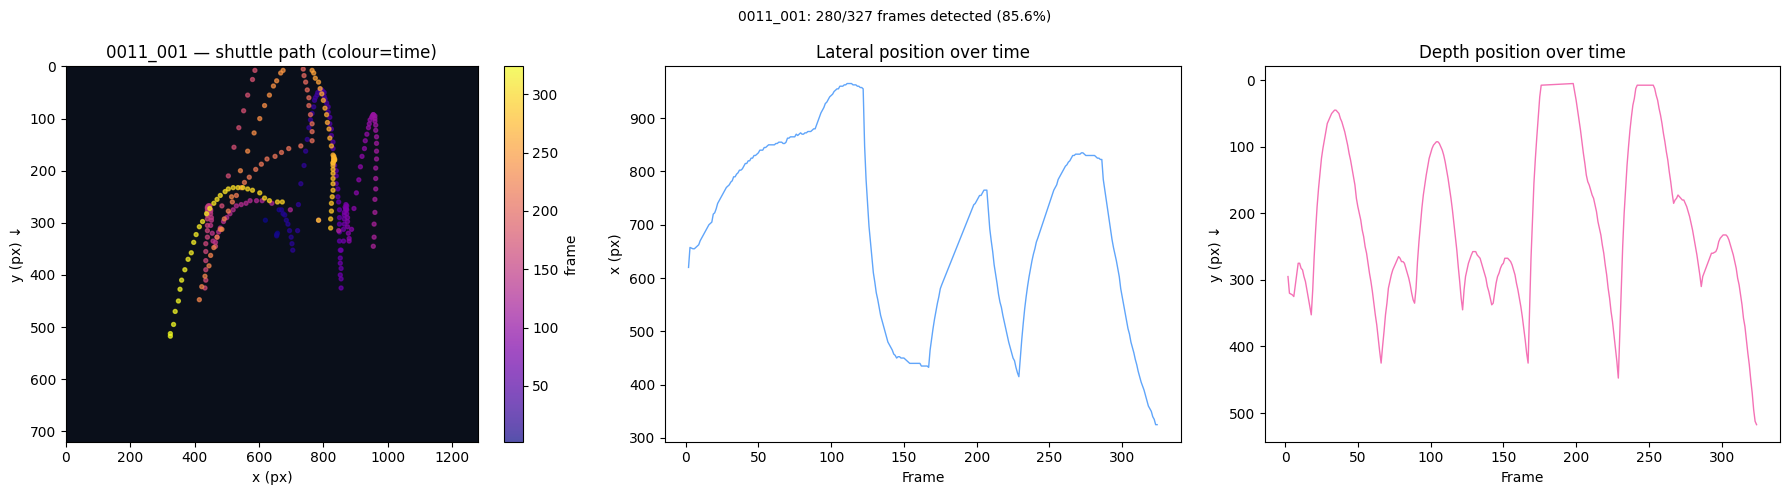

In [7]:
done_files = sorted(SHUTTLE_DIR.glob('*.npy'))
if not done_files:
    print('No trajectory files yet.')
else:
    for traj_file in done_files[:2]:
        rally_id = traj_file.stem
        traj = np.load(traj_file)   # (T, 3)
        vis  = traj[:, 2] > 0
        xs, ys = traj[vis, 0], traj[vis, 1]
        ts = np.where(vis)[0]

        fig, axes = plt.subplots(1, 3, figsize=(18, 5))

        # x-y trajectory
        sc = axes[0].scatter(xs, ys, c=ts, cmap='plasma', s=8, alpha=0.7)
        axes[0].invert_yaxis()
        axes[0].set_xlim(0, 1280); axes[0].set_ylim(720, 0)
        axes[0].set_xlabel('x (px)'); axes[0].set_ylabel('y (px) ↓')
        axes[0].set_title(f'{rally_id} — shuttle path (colour=time)')
        axes[0].set_facecolor('#0a0f1a')
        plt.colorbar(sc, ax=axes[0], label='frame')

        # x over time
        axes[1].plot(ts, xs, lw=1, color='#60a5fa')
        axes[1].set_xlabel('Frame'); axes[1].set_ylabel('x (px)')
        axes[1].set_title('Lateral position over time')

        # y over time
        axes[2].plot(ts, ys, lw=1, color='#f472b6')
        axes[2].invert_yaxis()
        axes[2].set_xlabel('Frame'); axes[2].set_ylabel('y (px) ↓')
        axes[2].set_title('Depth position over time')

        detection_rate = vis.mean() * 100
        plt.suptitle(f'{rally_id}: {vis.sum()}/{len(vis)} frames detected ({detection_rate:.1f}%)', fontsize=10)
        plt.tight_layout()
        plt.show()


## 7. Summary

In [8]:
done_files = sorted(SHUTTLE_DIR.glob('*.npy'))
print(f'Shuttle trajectory files: {len(done_files)} / 40 rallies')
total_vis = total_frames = 0
for f in done_files:
    t = np.load(f)
    total_frames += len(t)
    total_vis    += int(t[:, 2].sum())
    rate = t[:, 2].mean() * 100
    print(f'  {f.stem}: T={len(t)}, detected={int(t[:,2].sum())} ({rate:.0f}%)')
if total_frames:
    print(f'\nOverall detection rate: {total_vis}/{total_frames} ({100*total_vis/total_frames:.1f}%)')


Shuttle trajectory files: 1 / 40 rallies
  0011_001: T=327, detected=280 (86%)

Overall detection rate: 280/327 (85.6%)
